In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.datasets import make_blobs

In [2]:
X,y=make_blobs(n_samples=1000, centers=3,n_features=2, random_state=101)

In [3]:
X

array([[  3.33793405,   6.88729252],
       [  0.23867411,   2.11191814],
       [ -8.89358376,  -8.03957984],
       ...,
       [-11.42071284,  -5.76980566],
       [  0.56609951,   3.41000402],
       [  3.54839071,   8.18491039]], shape=(1000, 2))

In [5]:
y ## actual output of the clusters

array([2, 0, 1, 0, 2, 0, 2, 1, 2, 2, 2, 2, 0, 2, 1, 0, 1, 2, 2, 1, 0, 1,
       1, 1, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 2, 1, 1, 2, 2, 2, 0, 0, 2, 0,
       1, 2, 2, 0, 1, 0, 2, 1, 2, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0, 2, 1, 2,
       0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 0, 2,
       1, 0, 2, 0, 1, 0, 1, 1, 1, 2, 0, 0, 0, 1, 1, 0, 1, 2, 1, 1, 1, 2,
       1, 0, 2, 0, 0, 0, 1, 0, 1, 1, 2, 2, 0, 1, 0, 1, 0, 1, 2, 2, 1, 2,
       0, 2, 1, 2, 0, 0, 0, 2, 0, 2, 1, 1, 0, 2, 1, 0, 0, 2, 2, 0, 0, 2,
       2, 2, 0, 1, 2, 1, 2, 0, 2, 1, 1, 2, 0, 2, 1, 2, 0, 2, 1, 2, 2, 1,
       0, 2, 1, 0, 0, 1, 0, 0, 2, 2, 2, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0,
       2, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 2, 0, 1,
       0, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 0, 1,
       2, 1, 1, 2, 0, 1, 2, 2, 1, 2, 0, 1, 2, 0, 1, 1, 0, 1, 2, 1, 2, 0,
       0, 0, 1, 2, 0, 2, 2, 2, 2, 1, 2, 1, 0, 0, 2, 1, 0, 1, 2, 1, 0, 0,
       0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 1, 0, 1, 0, 0,

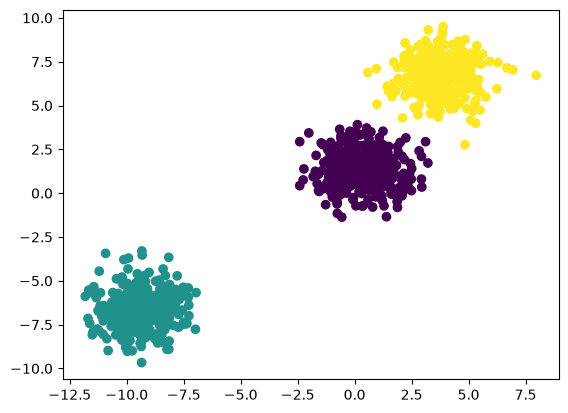

In [6]:
plt.scatter(X[:,0],X[:,1],c=y)

In [7]:
##standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=101)

In [9]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method to select K value
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=101)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1340.0000000000005,
 190.62969925277727,
 46.361590027704366,
 41.36076652137422,
 36.26264617064176,
 30.67107285468665,
 28.874333553293866,
 26.033701590593942,
 23.04243274590305,
 19.47535385063747]

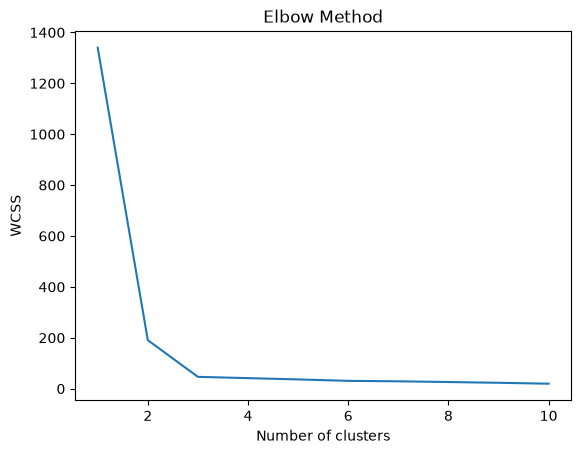

In [13]:
##plot elbow curve
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

U can see from 3 It was almost stable

In [14]:
kmeans=KMeans(n_clusters=3,init='k-means++',random_state=101)

In [15]:
kmeans.fit_predict(X_train)

array([1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2,
       0, 2, 1, 2, 1, 0, 0, 2, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 0, 2,
       0, 2, 1, 1, 2, 0, 1, 0, 2, 2, 0, 2, 2, 1, 2, 1, 1, 0, 0, 2, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 1, 0, 2, 1, 2, 2, 2,
       2, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 1, 2, 0, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 1, 0, 1, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 1, 1, 0, 2, 0, 2, 2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 1, 2, 2, 2,
       1, 0, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 1, 2, 2, 1, 0, 1, 2, 0, 0,
       1, 0, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 1, 2, 1, 2, 0, 2, 2,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 2, 2, 1, 0, 0, 0, 2, 2, 1, 2,
       0, 2, 1, 1, 2, 1, 1, 2, 2, 0, 2, 0, 2, 2, 1, 2, 2, 1, 0, 0, 2, 0,
       0, 1, 2, 2, 0, 2, 1, 0, 1, 0, 0, 1, 2, 2, 0, 2, 2, 2, 1, 1, 0, 0,
       0, 0, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2,
       0, 1, 1, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1,

In [16]:
y_pred=kmeans.predict(X_test)

In [17]:
y_pred

array([1, 1, 2, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2, 1, 0,
       0, 2, 0, 1, 0, 1, 0, 1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 1, 0, 1, 2,
       2, 2, 1, 1, 1, 0, 1, 2, 1, 2, 1, 1, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0,
       2, 0, 1, 2, 2, 1, 0, 1, 0, 0, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 1, 0,
       1, 1, 0, 1, 1, 2, 2, 2, 2, 0, 1, 1, 2, 1, 1, 0, 1, 2, 1, 1, 0, 1,
       2, 1, 0, 1, 1, 2, 0, 1, 1, 2, 1, 0, 1, 2, 1, 1, 2, 0, 2, 2, 1, 1,
       0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1, 2, 1, 2, 0,
       2, 2, 1, 0, 1, 1, 2, 0, 2, 2, 0, 1, 1, 1, 0, 0, 2, 2, 1, 2, 0, 2,
       2, 0, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 0, 2, 2, 1,
       0, 0, 0, 1, 2, 1, 2, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 2, 1, 1, 1, 0,
       1, 2, 0, 0, 2, 1, 1, 2, 0, 2, 0, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 2,
       0, 2, 0, 2, 2, 0, 1, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 1, 1, 1, 1, 2,
       2, 2, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 2,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 2, 0,

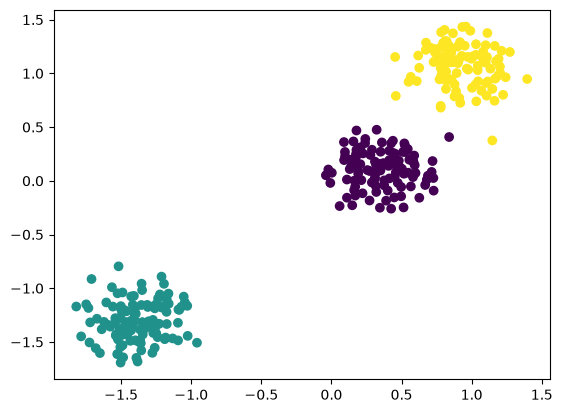

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

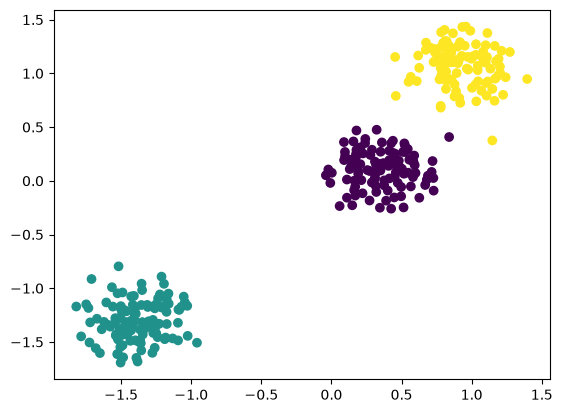

In [19]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)

## Validating K value

In [21]:
!pip install kneed

In [22]:
## if it is difficult to find the elbow point, we can use kneed library to find the optimal value of K
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [23]:
kl.elbow

np.int64(2)

In [24]:
##silhouette score to evaluate the model
from sklearn.metrics import silhouette_score
sil_coeff=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=101)
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    sil_coeff.append(score)

In [25]:
sil_coeff

[0.7742078781192541,
 0.7547825640461435,
 0.5867942933737793,
 0.43733078931413355,
 0.3188063804840268,
 0.29868810055016465,
 0.3230111020399939,
 0.3248097368636525,
 0.335888459711536]

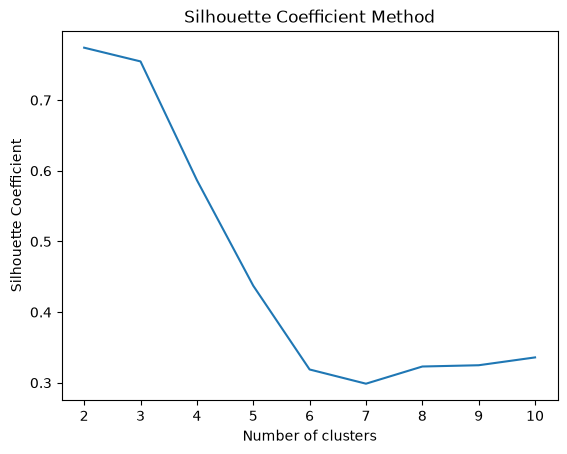

In [26]:
plt.plot(range(2,11),sil_coeff)
plt.title('Silhouette Coefficient Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.show()

Hierarichal Clustering

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [29]:
from sklearn import datasets
iris=datasets.load_iris()
iris_data=pd.DataFrame(data=iris.data,columns=iris.feature_names)


In [30]:
iris_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [32]:
X_scaled=scaler.fit_transform(iris_data)

In [33]:
## apply pca to reduce the dimensions of the data to 2D for visualization
from sklearn.decomposition import PCA

In [34]:
pca=PCA(n_components=2)

In [35]:
pca_scaled=pca.fit_transform(X_scaled)

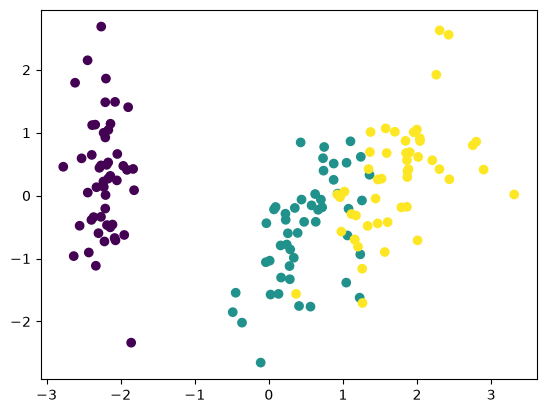

In [36]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=iris.target)

Text(0, 0.5, 'Euclidean distances')

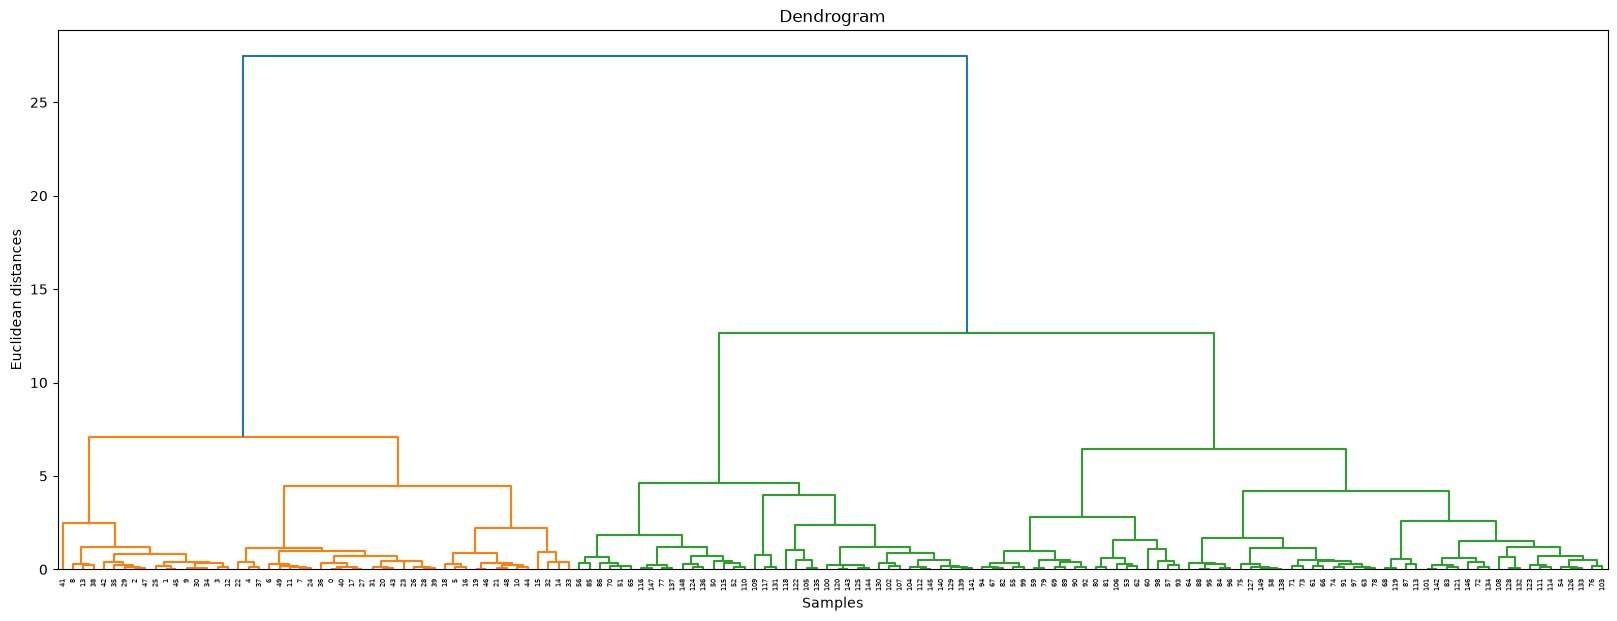

In [38]:
## agglomerative clustering
## construct dendrogram to find the optimal number of clusters
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(20,7))
plt.title('Dendrogram')
sch.dendrogram(sch.linkage(pca_scaled,method='ward'))
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')

select the vertical such that it doesnot pass through any horizontal line

In [40]:
##cluster=2
from sklearn.cluster import AgglomerativeClustering
clustering=AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
clustering.fit(pca_scaled)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",2
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" and ""l2"" are accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False
Name,Type,Value
"children_ children_: array-like of shape (n_samples-1, 2)The children of each non-leaf node. Values less than `n_samples`correspond to leaves of the tree which are the original samples.A node `i` greater than or equal to `n_sampl

In [41]:
clustering.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

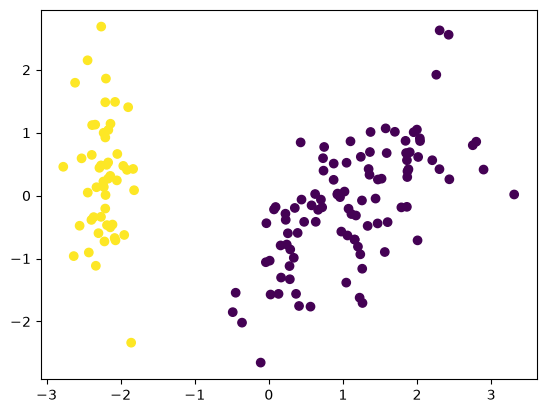

In [42]:
plt.scatter(pca_scaled[:,0],pca_scaled[:,1],c=clustering.labels_)

DBSCAN

In [43]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
%matplotlib inline

In [45]:
X,y = make_moons(n_samples=250,noise=0.05)

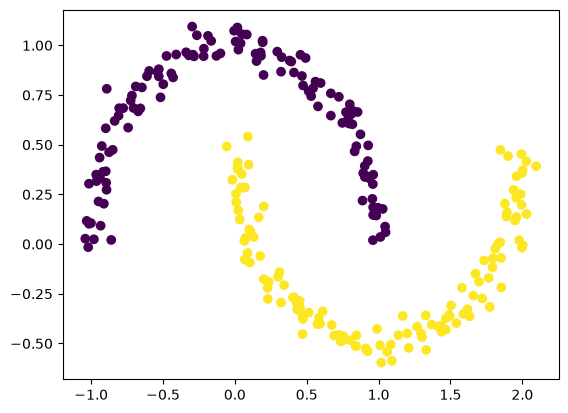

In [46]:
plt.scatter(X[:,0],X[:,1],c=y)

In [47]:
# scaling the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [48]:
X_scaled=scaler.fit_transform(X)

In [49]:
dbscan=DBSCAN(eps=0.3)

In [50]:
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](249, 2)","[[ 0.6 ,-0.15], [-0.04,-1.23], [ 0.39, 0.49], ..., [ 0.76,-1.23], [-1.6 , 1.07], [ 0.47, 0.19]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](249,)","[ 0, 1, 2,...,247,248,249]"


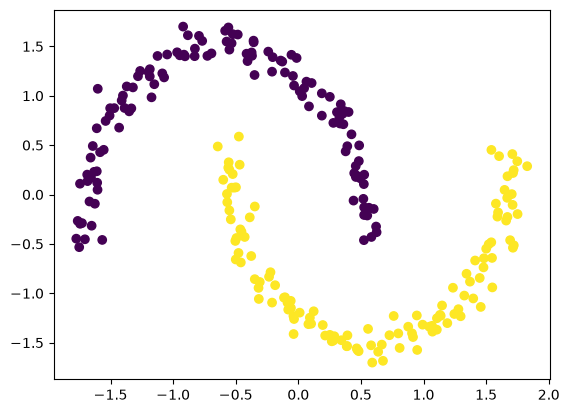

In [51]:
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=dbscan.labels_)